In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skops.io as sio
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pl.read_csv('DataCleaned.csv')
feature_names = df.drop('Class').columns
df.head()

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
10,10,10,6,8,4,8,5,1,4
5,1,1,1,2,1,3,1,1,2
4,1,1,1,2,2,3,2,1,2
3,1,1,1,2,2,7,1,1,2
9,8,8,9,6,3,4,1,1,4


In [ ]:
X = df.drop('Class').to_numpy()
y = df['Class'].to_numpy()


X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=27
)

print(f"Full Training set: {len(X_train_full)} samples")
print(f"Holdout Test set:  {len(X_test)} samples")
print(f"Full Training set: {len(y_train_full)} samples")
print(f"Holdout Test set:  {len(y_test)} samples")

Full Training set: 540 samples
Holdout Test set:  135 samples
Full Training set: 540 samples
Holdout Test set:  135 samples


(135,)

In [18]:

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=27)
variance_threshold = 0.80
required_components = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), 1):
    X_f_train = X_train_full[train_idx]
    
    
    scaler_fold = StandardScaler()
    X_f_train_scaled = scaler_fold.fit_transform(X_f_train)
    
    pca_fold = PCA().fit(X_f_train_scaled)
    cumulative_variance = np.cumsum(pca_fold.explained_variance_ratio_)
    
    n_comp = np.argmax(cumulative_variance >= variance_threshold) + 1
    required_components.append(n_comp)
    print(f"Fold {fold}: {n_comp} components needed for {variance_threshold*100}% variance")

optimal_n = int(np.max(required_components))
print(f"\nProfessional Choice for Modeling: {optimal_n} components")

Fold 1: 3 components needed for 80.0% variance
Fold 2: 3 components needed for 80.0% variance
Fold 3: 3 components needed for 80.0% variance
Fold 4: 3 components needed for 80.0% variance
Fold 5: 3 components needed for 80.0% variance

Professional Choice for Modeling: 3 components


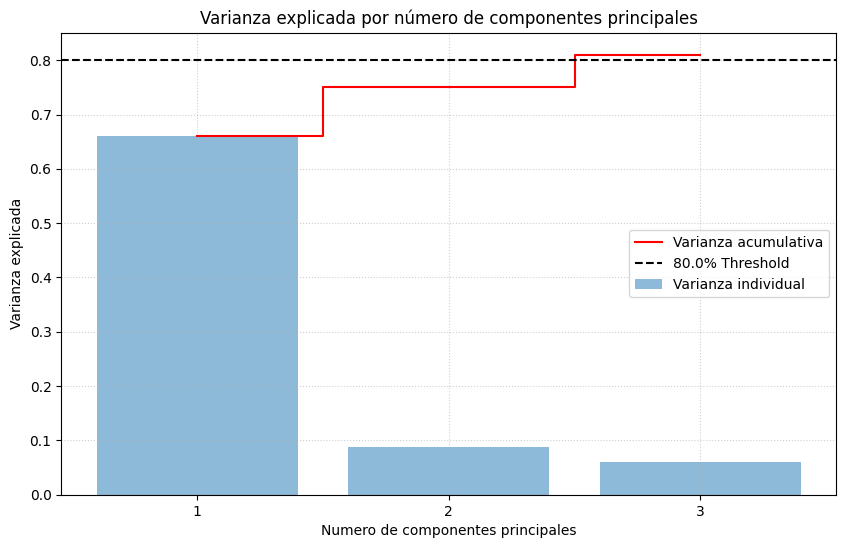

In [19]:

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_full)
pca_full = PCA(n_components=optimal_n).fit(X_train_scaled)

exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.5, align='center', label='Varianza individual')
plt.step(range(1, len(cum_var)+1), cum_var, where='mid', label='Varianza acumulativa', color='red')
plt.axhline(y=variance_threshold, color='black', linestyle='--', label=f'{variance_threshold*100}% Threshold')
plt.title('Varianza explicada por número de componentes principales')
plt.xlabel('Numero de componentes principales')
plt.ylabel('Varianza explicada')
plt.xticks(range(1, len(exp_var)+1))
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

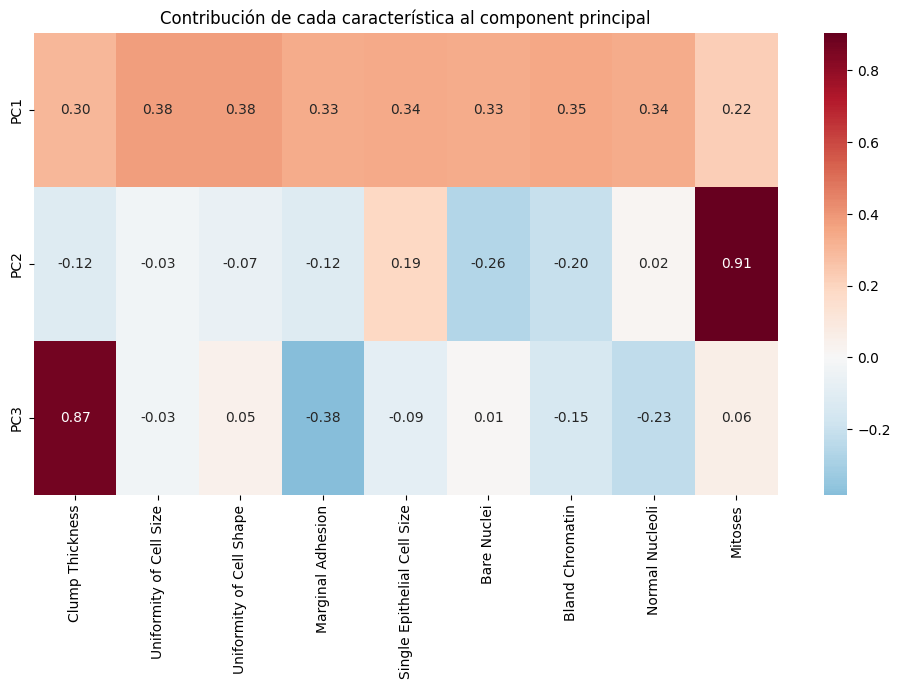

In [21]:

plt.figure(figsize=(12, 6))
sns.heatmap(pca_full.components_, 
            cmap='RdBu_r', annot=True, fmt='.2f', 
            xticklabels=feature_names, 
            yticklabels=['PC1', 'PC2', 'PC3'],
            center=0)
plt.title('Contribución de cada característica al component principal')
plt.show()

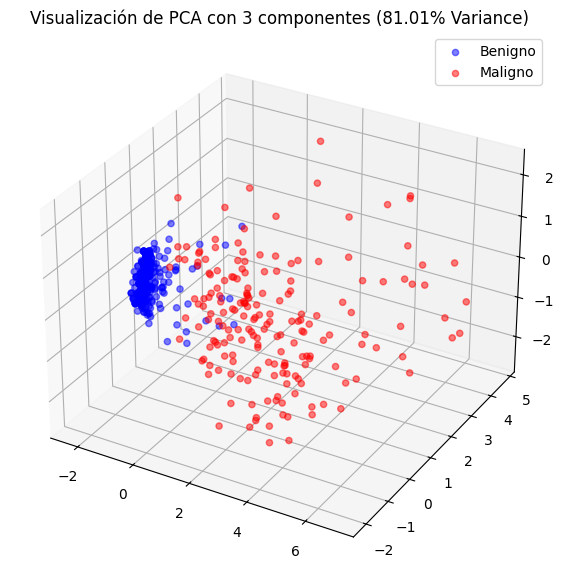

In [23]:


X_pca_3d = pca_full.fit_transform(X_train_scaled)
var_3d = np.sum(pca_full.explained_variance_ratio_) * 100

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for target, color, label in [(2, 'blue', 'Benigno'), (4, 'red', 'Maligno')]:
    indices = y_train_full == target
    ax.scatter(X_pca_3d[indices, 0], X_pca_3d[indices, 1], X_pca_3d[indices, 2], 
               c=color, label=label, alpha=0.5)

ax.set_title(f'Visualización de PCA con {optimal_n} componentes ({var_3d:.2f}% Variance)')
ax.legend()
plt.show()

In [ ]:

pca_final = PCA(n_components=optimal_n)
X_train_pca = pca_final.fit_transform(X_train_scaled)


X_test_scaled = scaler_final.transform(X_test)
X_test_pca = pca_final.transform(X_test_scaled)

sio.dump(scaler_final, 'scaler.skops')
sio.dump(pca_final, 'pca_model.skops')

np.save('X_train_pca.npy', X_train_pca)
np.save('X_test_pca.npy', X_test_pca)
np.save('y_train.npy', y_train_full)
np.save('y_test.npy', y_test)

print(f"Varianza retenida por el PCA final (n={optimal_n}): {np.sum(pca_final.explained_variance_ratio_)*100:.2f}%")

Varianza retenida por el PCA final (n=3): 81.01%
